<a href="https://colab.research.google.com/github/babiologa/Bioestat-stica/blob/main/tarefa13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Barbara Aimy Baldin
##Dante Gomes SOares de Morais
##Marina de Oliveira Cappato

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import norm, t, chi2, f

plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

colunas = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]

df = pd.read_csv(url, header=None, names=colunas)

df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
print("Dimensões da base:", df.shape)

print("\nTipos das variáveis:")
print(df.dtypes)

print("\nValores ausentes:")
print(df.isna().sum())

print("\nNúmero de observações por espécie:")
print(df["species"].value_counts())


Dimensões da base: (150, 5)

Tipos das variáveis:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Valores ausentes:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Número de observações por espécie:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


Neste trabalho foram utilizadas todas as 150 observações disponíveis na base Iris.

Não foram criados dados fictícios.

Também não foram imputados valores ausentes, pois a documentação da UCI informa que a base não apresenta valores ausentes.

Para as análises envolvendo comparação entre dois grupos, serão utilizadas as espécies:

    Iris versicolor;

    Iris virginica.

A variável principal escolhida será o comprimento da pétala, medido em centímetros.

A escolha permite estudar tanto uma medida individual quanto estatísticas derivadas de amostras de dois grupos.


As análises serão organizadas em torno das seguintes perguntas:

**Pergunta 1 — Normal**

Qual a probabilidade de uma nova planta do grupo analisado apresentar comprimento de pétala dentro de determinado intervalo, assumindo um modelo Normal?

Essa pergunta trata de uma medida individual.

**Pergunta 2 — t de Student**

Quão compatível é uma média amostral de comprimento de pétala com uma média populacional hipotética de 5,5 cm?

Aqui a quantidade analisada é uma estatística padronizada, calculada a partir de uma amostra.

**Pergunta 3 — qui-quadrado**

Quão compatível é a variabilidade observada no comprimento da pétala de Iris virginica com uma variância populacional de referência de 0,25 cm²?

Aqui a quantidade analisada é uma estatística construída a partir da variância amostral.

**Pergunta 4 — F de Fisher**

A razão entre as variâncias do comprimento da pétala de Iris virginica e Iris versicolor é compatível com a distribuição esperada sob igualdade das variâncias?

Essa análise utiliza duas amostras independentes.

In [4]:
df.groupby("species")[
    ["sepal_length", "sepal_width", "petal_length", "petal_width"]
].agg(["mean", "std", "var", "min", "max"])


sepal_length                               sepal_width  \
                        mean       std       var  min  max        mean   
species                                                                  
Iris-setosa            5.006  0.352490  0.124249  4.3  5.8       3.418   
Iris-versicolor        5.936  0.516171  0.266433  4.9  7.0       2.770   
Iris-virginica         6.588  0.635880  0.404343  4.9  7.9       2.974   

                                              petal_length            \
                      std       var  min  max         mean       std   
species                                                                
Iris-setosa      0.381024  0.145180  2.3  4.4        1.464  0.173511   
Iris-versicolor  0.313798  0.098469  2.0  3.4        4.260  0.469911   
Iris-virginica   0.322497  0.104004  2.2  3.8        5.552  0.551895   

                                    petal_width                                
                      var  min  max        mean       std       var  min  max  
species                                                                        
Iris-setosa      0.030106  1.0  1.9       0.244  0.107210  0.011494  0.1  0.6  
Iris-versicolor  0.220816  3.0  5.1       1.326  0.197753  0.039106  1.0  1.8  
Iris-virginica   0.304588  4.5  6.9       2.026  0.274650  0.075433  1.4  2.5

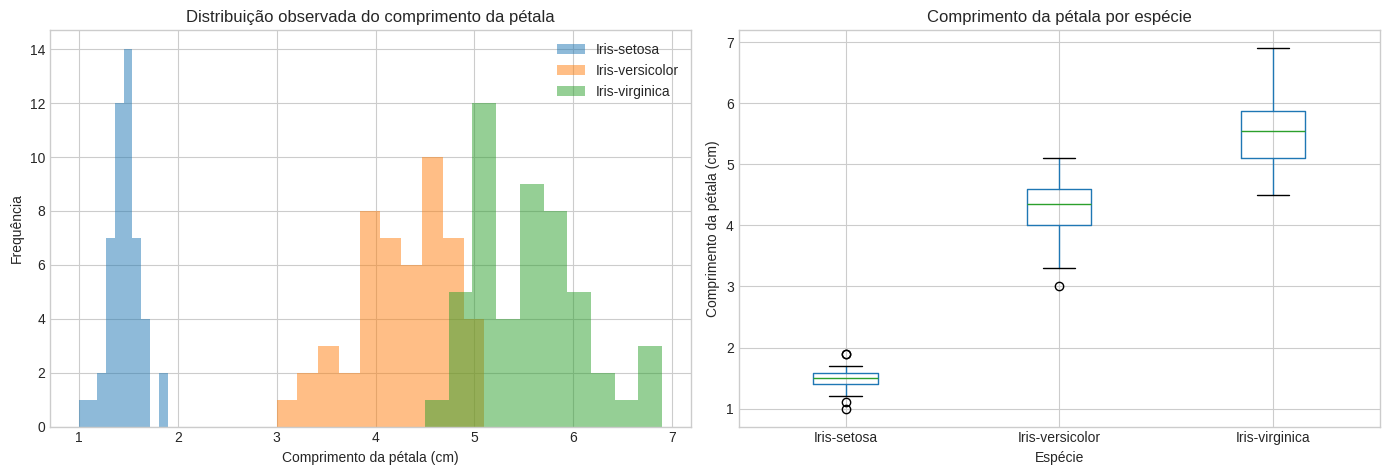

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for species, grupo in df.groupby("species"):
    axes[0].hist(
        grupo["petal_length"],
        bins=10,
        alpha=0.5,
        label=species
    )

axes[0].set_title("Distribuição observada do comprimento da pétala")
axes[0].set_xlabel("Comprimento da pétala (cm)")
axes[0].set_ylabel("Frequência")
axes[0].legend()

df.boxplot(
    column="petal_length",
    by="species",
    ax=axes[1]
)

axes[1].set_title("Comprimento da pétala por espécie")
axes[1].set_xlabel("Espécie")
axes[1].set_ylabel("Comprimento da pétala (cm)")

plt.suptitle("")
plt.tight_layout()
plt.show()


**Distribuição Normal**

A distribuição Normal é uma distribuição contínua caracterizada por dois parâmetros:

    μ: média;

    σ: desvio-padrão.

Sua função densidade é:

f(x∣μ,σ)=1σ2πexp⁡[−12(x−μσ)2]

com:

−∞<x<∞

e

σ>0.

A documentação do SciPy apresenta exatamente essa parametrização, com μ como parâmetro de localização e σ como desvio-padrão.
Interpretação dos parâmetros

    μ determina a posição central da curva.

    σ controla sua dispersão.

    Aumentar μ desloca a curva para a direita.

    Aumentar σ deixa a curva mais larga e baixa.

    A Normal é simétrica em torno de μ.

Neste trabalho, a Normal será utilizada como modelo aproximado para uma medida biológica individual, e não como uma afirmação automática de que os dados seguem exatamente essa distribuição.

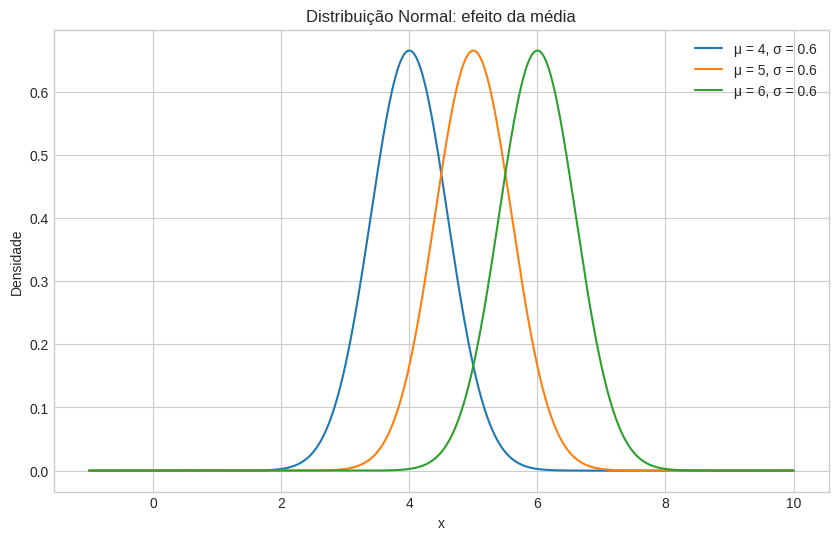

In [6]:
x = np.linspace(-1, 10, 1000)

medias = [4, 5, 6]
sigma = 0.6

plt.figure(figsize=(10, 6))

for mu in medias:
    plt.plot(
        x,
        norm.pdf(x, loc=mu, scale=sigma),
        label=f"μ = {mu}, σ = {sigma}"
    )

plt.title("Distribuição Normal: efeito da média")
plt.xlabel("x")
plt.ylabel("Densidade")
plt.legend()
plt.show()


Mantendo o desvio-padrão fixo, modificar μ apenas desloca a curva horizontalmente.

A forma e a dispersão permanecem iguais.

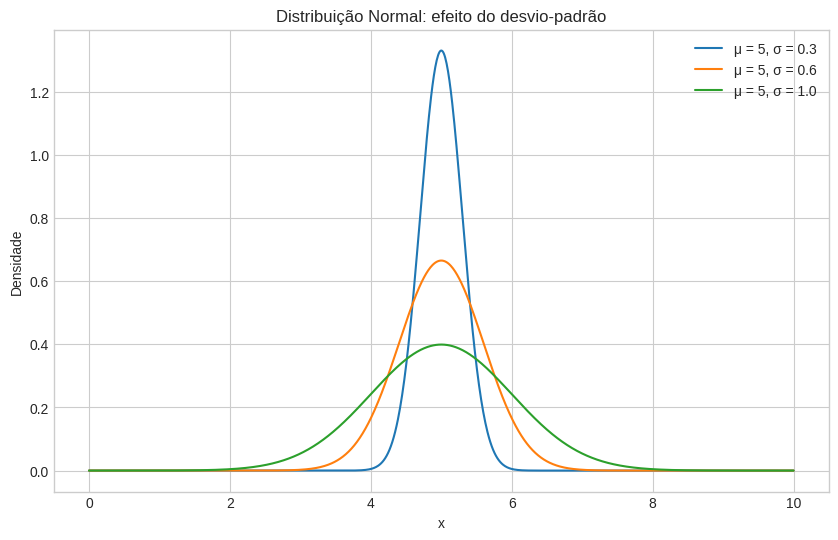

In [7]:
x = np.linspace(0, 10, 1000)

mu = 5

desvios = [0.3, 0.6, 1.0]

plt.figure(figsize=(10, 6))

for sigma in desvios:
    plt.plot(
        x,
        norm.pdf(x, loc=mu, scale=sigma),
        label=f"μ = {mu}, σ = {sigma}"
    )

plt.title("Distribuição Normal: efeito do desvio-padrão")
plt.xlabel("x")
plt.ylabel("Densidade")
plt.legend()
plt.show()


Quando σ aumenta:

    a distribuição fica mais dispersa;

    o pico diminui;

    a curva se torna mais larga.

A área total sob cada curva continua sendo 1.

In [8]:
virginica = df[df["species"] == "Iris-virginica"]["petal_length"]

mu_virginica = virginica.mean()
sigma_virginica = virginica.std(ddof=1)

print(f"Média = {mu_virginica:.4f} cm")
print(f"Desvio-padrão = {sigma_virginica:.4f} cm")


Média = 5.5520 cm
Desvio-padrão = 0.5519 cm


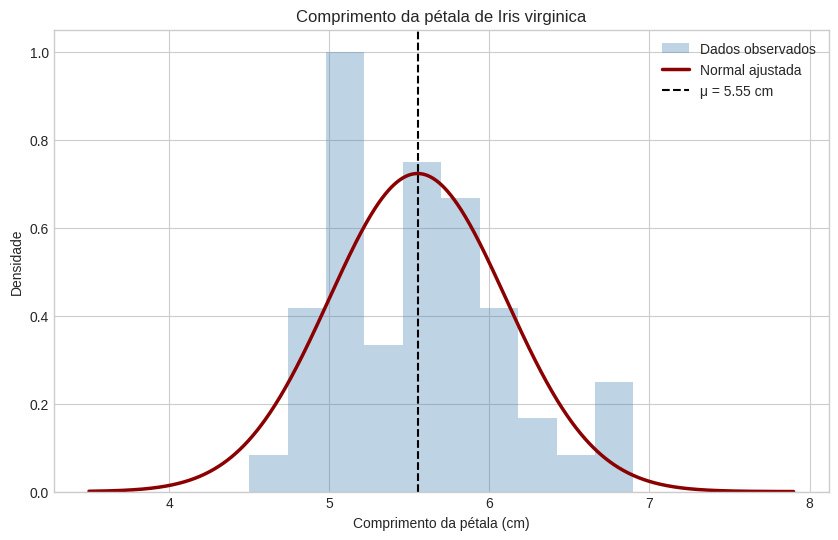

In [9]:
x = np.linspace(
    virginica.min() - 1,
    virginica.max() + 1,
    1000
)

densidade = norm.pdf(
    x,
    loc=mu_virginica,
    scale=sigma_virginica
)

plt.figure(figsize=(10, 6))

plt.hist(
    virginica,
    bins=10,
    density=True,
    alpha=0.35,
    color="steelblue",
    label="Dados observados"
)

plt.plot(
    x,
    densidade,
    color="darkred",
    linewidth=2.5,
    label="Normal ajustada"
)

plt.axvline(
    mu_virginica,
    color="black",
    linestyle="--",
    label=f"μ = {mu_virginica:.2f} cm"
)

plt.title("Comprimento da pétala de Iris virginica")
plt.xlabel("Comprimento da pétala (cm)")
plt.ylabel("Densidade")
plt.legend()
plt.show()


A curva Normal representa um modelo aproximado para a distribuição de uma nova medida individual de comprimento da pétala.

O histograma representa os dados observados.

A curva não prova que os dados são Normalmente distribuídos. Para avaliar a adequação do modelo, também devemos considerar a forma dos dados, possíveis assimetrias, tamanho amostral e independência das observações.

Vamos calcular:

P(X≤5)

ou seja, a probabilidade modelada de uma planta apresentar comprimento de pétala de até 5 cm.

In [10]:
limite = 5

p_acumulada = norm.cdf(
    limite,
    loc=mu_virginica,
    scale=sigma_virginica
)

print(f"P(X ≤ {limite}) = {p_acumulada:.4f}")


P(X ≤ 5) = 0.1586


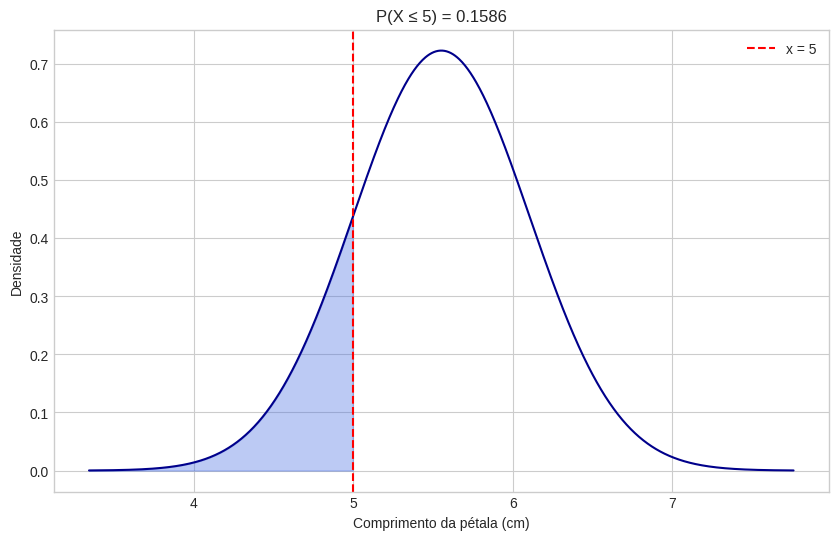

In [11]:
x = np.linspace(
    mu_virginica - 4*sigma_virginica,
    mu_virginica + 4*sigma_virginica,
    1000
)

y = norm.pdf(
    x,
    mu_virginica,
    sigma_virginica
)

plt.figure(figsize=(10, 6))
plt.plot(x, y, color="darkblue")

mask = x <= limite

plt.fill_between(
    x[mask],
    y[mask],
    alpha=0.35,
    color="royalblue"
)

plt.axvline(
    limite,
    color="red",
    linestyle="--",
    label=f"x = {limite}"
)

plt.title(
    f"P(X ≤ {limite}) = {p_acumulada:.4f}"
)

plt.xlabel("Comprimento da pétala (cm)")
plt.ylabel("Densidade")
plt.legend()
plt.show()


A área sombreada corresponde numericamente à probabilidade calculada pela CDF.

Agora calcularemos, para probabilidade entre dois valores:

P(5≤X≤6)

In [12]:
a = 5
b = 6

p_intervalo = (
    norm.cdf(b, mu_virginica, sigma_virginica)
    -
    norm.cdf(a, mu_virginica, sigma_virginica)
)

print(f"P({a} ≤ X ≤ {b}) = {p_intervalo:.4f}")


P(5 ≤ X ≤ 6) = 0.6329


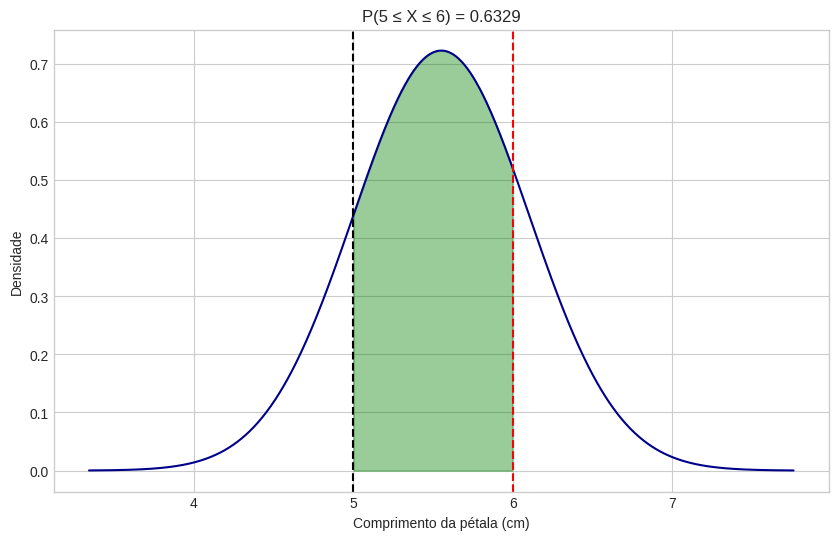

In [13]:
x = np.linspace(
    mu_virginica - 4*sigma_virginica,
    mu_virginica + 4*sigma_virginica,
    1000
)

y = norm.pdf(x, mu_virginica, sigma_virginica)

plt.figure(figsize=(10, 6))
plt.plot(x, y, color="darkblue")

mask = (x >= a) & (x <= b)

plt.fill_between(
    x[mask],
    y[mask],
    alpha=0.4,
    color="green"
)

plt.axvline(a, color="black", linestyle="--")
plt.axvline(b, color="red", linestyle="--")

plt.title(
    f"P({a} ≤ X ≤ {b}) = {p_intervalo:.4f}"
)

plt.xlabel("Comprimento da pétala (cm)")
plt.ylabel("Densidade")
plt.show()


Agora, para probabilidade acima de um valor:

P(X>6)

In [14]:
limite_superior = 6

p_acima = norm.sf(
    limite_superior,
    loc=mu_virginica,
    scale=sigma_virginica
)

print(f"P(X > {limite_superior}) = {p_acima:.4f}")


P(X > 6) = 0.2085


Usamos sf porque ela calcula diretamente a probabilidade da cauda superior. O SciPy define sf como a função de sobrevivência, equivalente a 1−CDF, e observa que ela pode ser numericamente mais precisa em algumas situações.

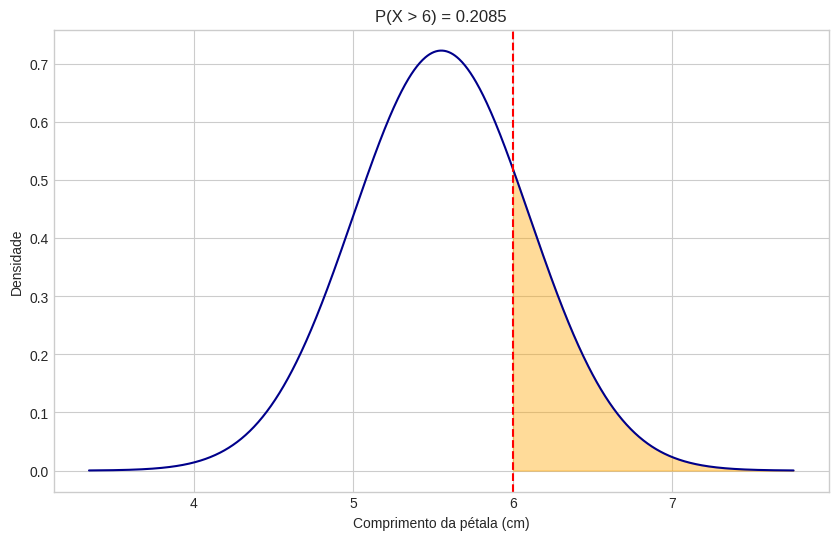

In [15]:
x = np.linspace(
    mu_virginica - 4*sigma_virginica,
    mu_virginica + 4*sigma_virginica,
    1000
)

y = norm.pdf(x, mu_virginica, sigma_virginica)

plt.figure(figsize=(10, 6))
plt.plot(x, y, color="darkblue")

mask = x >= limite_superior

plt.fill_between(
    x[mask],
    y[mask],
    alpha=0.4,
    color="orange"
)

plt.axvline(
    limite_superior,
    color="red",
    linestyle="--"
)

plt.title(
    f"P(X > {limite_superior}) = {p_acima:.4f}"
)

plt.xlabel("Comprimento da pétala (cm)")
plt.ylabel("Densidade")
plt.show()


Vamos calcular o percentil 95:

x0,95=F−1(0,95)

In [16]:
percentil_95_normal = norm.ppf(
    0.95,
    loc=mu_virginica,
    scale=sigma_virginica
)

print(
    f"Percentil 95 = {percentil_95_normal:.4f} cm"
)


Percentil 95 = 6.4598 cm


O ppf é a função inversa da CDF. Assim, aproximadamente 95% da distribuição modelada está abaixo desse valor.

**Interpretação da distribuição t**

A distribuição t é especialmente importante quando uma média populacional é inferida a partir de uma amostra Normal e o desvio-padrão populacional é desconhecido.

Para uma amostra de tamanho n, a estatística de uma amostra é:

T=Xˉ−μ0s/n

onde:

    Xˉ = média amostral;

    μ0 = média populacional hipotética;

    s = desvio-padrão amostral;

    n = tamanho da amostra.

Sob as condições apropriadas:

T∼tn−1.

Portanto, a distribuição t não representa diretamente o comprimento das pétalas.

Ela representa a distribuição de uma estatística padronizada.

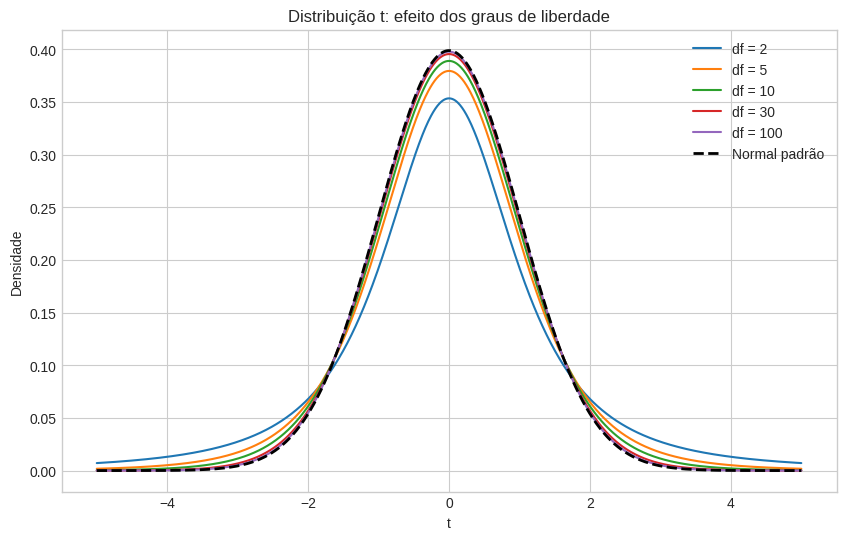

In [17]:
x = np.linspace(-5, 5, 1000)

dfs = [2, 5, 10, 30, 100]

plt.figure(figsize=(10, 6))

for df_graus in dfs:
    plt.plot(
        x,
        t.pdf(x, df_graus),
        label=f"df = {df_graus}"
    )

plt.plot(
    x,
    norm.pdf(x),
    "k--",
    linewidth=2,
    label="Normal padrão"
)

plt.title("Distribuição t: efeito dos graus de liberdade")
plt.xlabel("t")
plt.ylabel("Densidade")
plt.legend()
plt.show()


Com poucos graus de liberdade:

    as caudas são mais pesadas;

    há maior dispersão;

    valores extremos são mais prováveis.

À medida que os graus de liberdade aumentam, a curva se aproxima da Normal padrão.

Vamos testar como uma média observada se comportaria em relação a uma média populacional hipotética de:

μ0=5,5 cm.

In [18]:
amostra_t = virginica

n = len(amostra_t)
media = amostra_t.mean()
s = amostra_t.std(ddof=1)

mu0 = 5.5

t_observado = (media - mu0) / (s / np.sqrt(n))
df_t = n - 1

print(f"n = {n}")
print(f"Média amostral = {media:.4f} cm")
print(f"Desvio-padrão = {s:.4f} cm")
print(f"μ0 = {mu0:.2f} cm")
print(f"t observado = {t_observado:.4f}")
print(f"Graus de liberdade = {df_t}")


n = 50
Média amostral = 5.5520 cm
Desvio-padrão = 0.5519 cm
μ0 = 5.50 cm
t observado = 0.6662
Graus de liberdade = 49


Calcularemos, para probabilidade acumulada:

P(T≤tobs)

In [19]:
p_t_acumulada = t.cdf(
    t_observado,
    df=df_t
)

print(
    f"P(T ≤ {t_observado:.4f}) = "
    f"{p_t_acumulada:.6f}"
)


P(T ≤ 0.6662) = 0.745809


Essa probabilidade se refere à estatística t, não diretamente ao comprimento de uma pétala.

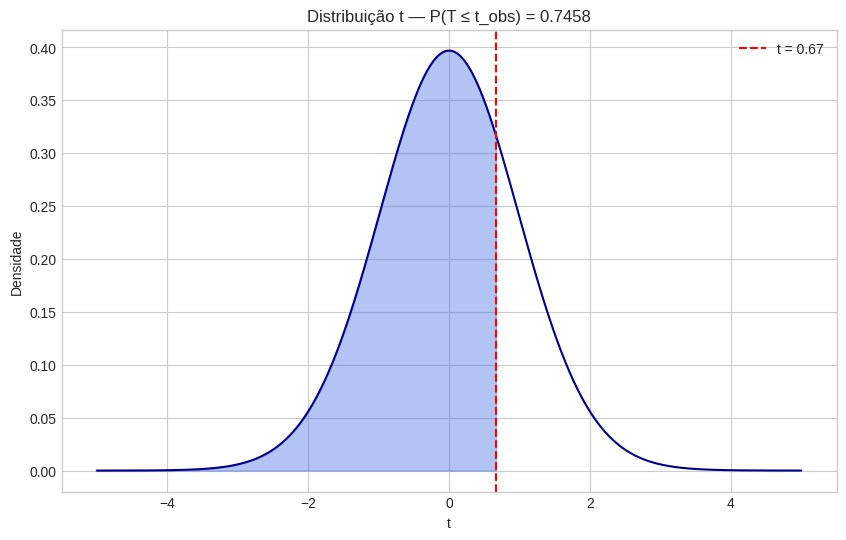

In [20]:
x = np.linspace(-5, 5, 1000)
y = t.pdf(x, df_t)

plt.figure(figsize=(10, 6))
plt.plot(x, y, color="darkblue")

mask = x <= t_observado

plt.fill_between(
    x[mask],
    y[mask],
    alpha=0.4,
    color="royalblue"
)

plt.axvline(
    t_observado,
    color="red",
    linestyle="--",
    label=f"t = {t_observado:.2f}"
)

plt.title(
    f"Distribuição t — P(T ≤ t_obs) = {p_t_acumulada:.4f}"
)

plt.xlabel("t")
plt.ylabel("Densidade")
plt.legend()
plt.show()


Vamos calcular, para demonstrar a probabilidade entre dois valores:

P(−2≤T≤2).

In [21]:
a_t = -2
b_t = 2

p_t_intervalo = (
    t.cdf(b_t, df_t)
    -
    t.cdf(a_t, df_t)
)

print(
    f"P({a_t} ≤ T ≤ {b_t}) = "
    f"{p_t_intervalo:.6f}"
)


P(-2 ≤ T ≤ 2) = 0.948941


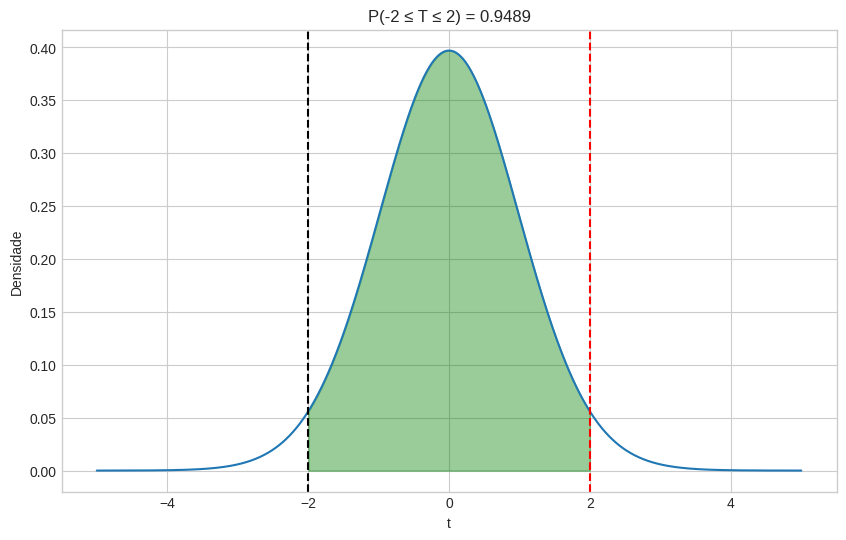

In [22]:
x = np.linspace(-5, 5, 1000)
y = t.pdf(x, df_t)

plt.figure(figsize=(10, 6))
plt.plot(x, y)

mask = (x >= a_t) & (x <= b_t)

plt.fill_between(
    x[mask],
    y[mask],
    alpha=0.4,
    color="green"
)

plt.axvline(a_t, color="black", linestyle="--")
plt.axvline(b_t, color="red", linestyle="--")

plt.title(
    f"P(-2 ≤ T ≤ 2) = {p_t_intervalo:.4f}"
)

plt.xlabel("t")
plt.ylabel("Densidade")
plt.show()


Vamos calcular, para demonstrar a probabilidade acima de um valor:

P(T>2).

In [23]:
limite_t = 2

p_t_acima = t.sf(
    limite_t,
    df=df_t
)

print(
    f"P(T > {limite_t}) = "
    f"{p_t_acima:.6f}"
)


P(T > 2) = 0.025530


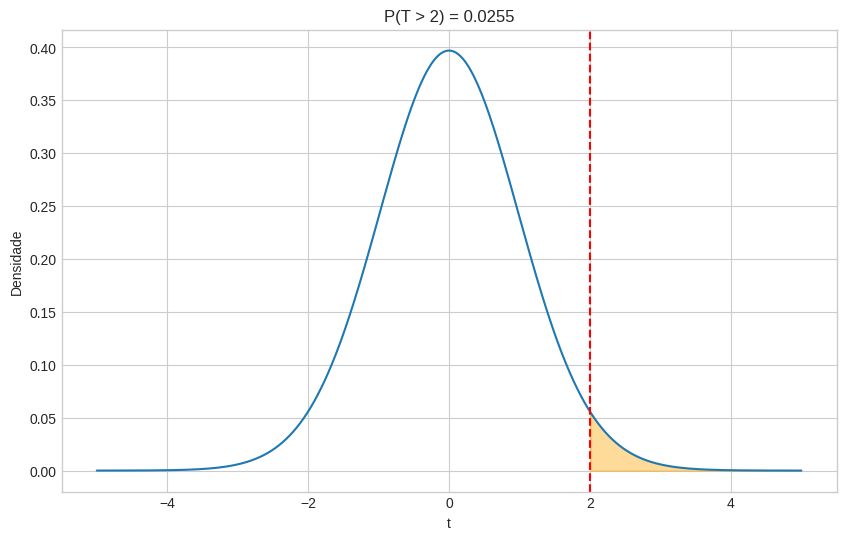

In [24]:
x = np.linspace(-5, 5, 1000)
y = t.pdf(x, df_t)

plt.figure(figsize=(10, 6))
plt.plot(x, y)

mask = x >= limite_t

plt.fill_between(
    x[mask],
    y[mask],
    alpha=0.4,
    color="orange"
)

plt.axvline(
    limite_t,
    color="red",
    linestyle="--"
)

plt.title(
    f"P(T > {limite_t}) = {p_t_acima:.4f}"
)

plt.xlabel("t")
plt.ylabel("Densidade")
plt.show()


Vamos encontrar o percentil 97,5%:

In [25]:
percentil_975_t = t.ppf(
    0.975,
    df=df_t
)

print(
    f"Percentil 97,5% da t = "
    f"{percentil_975_t:.4f}"
)


Percentil 97,5% da t = 2.0096


Esse valor significa que 97,5% da distribuição t com esses graus de liberdade está abaixo do valor calculado.

Podemos voltar da escala t para a escala da variável original:

Xˉ=μ0+tsn.

In [26]:
limite_superior_media = (
    mu0 +
    percentil_975_t * s / np.sqrt(n)
)

print(
    f"Valor correspondente na escala da média = "
    f"{limite_superior_media:.4f} cm"
)


Valor correspondente na escala da média = 5.6568 cm


Esse cálculo mostra a diferença entre:

    uma quantidade biológica, medida em centímetros;

    uma estatística padronizada, medida na escala t.


**Distribuição qui-quadrado**

A distribuição qui-quadrado com k graus de liberdade possui densidade:

f(x;k)=xk/2−1e−x/22k/2Γ(k/2)

para:

x>0,k>0.

A documentação do SciPy apresenta essa densidade e identifica k como os graus de liberdade.

O NIST também apresenta a mesma forma da densidade.

**Relação com a variância**

Se:

X1,…,Xn

são observações independentes de uma população Normal com variância σ2, então:

(n−1)S2σ2∼χn−12.

Aqui:

    S2 é a variância amostral;

    σ2 é a variância populacional;

    n−1 são os graus de liberdade.

Portanto, a distribuição qui-quadrado utilizada nesta análise é uma distribuição da estatística de variância, e não dos comprimentos individuais.


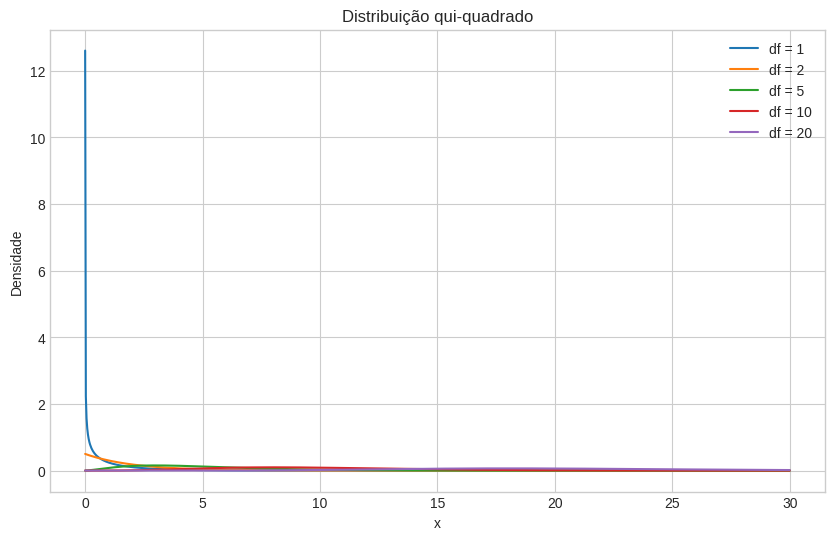

In [27]:
x = np.linspace(0.001, 30, 1000)

dfs = [1, 2, 5, 10, 20]

plt.figure(figsize=(10, 6))

for df_graus in dfs:
    plt.plot(
        x,
        chi2.pdf(x, df_graus),
        label=f"df = {df_graus}"
    )

plt.title("Distribuição qui-quadrado")
plt.xlabel("x")
plt.ylabel("Densidade")
plt.legend()
plt.show()


A distribuição qui-quadrado:

    só assume valores positivos;

    apresenta assimetria à direita para poucos graus de liberdade;

    torna-se mais concentrada e aproximadamente simétrica à medida que os graus de liberdade aumentam.


**Análise da variância de Iris virginica**

Vamos considerar como valor de referência:

σ02=0,25 cm2.

Isso corresponde a um desvio-padrão de:

σ0=0,5 cm.

A pergunta é:

    Se a variância populacional verdadeira fosse 0,25 cm², quão extrema seria a variância observada nesta amostra?


In [28]:
sigma0_2 = 0.25

s2 = virginica.var(ddof=1)
n_chi = len(virginica)

chi_observado = (
    (n_chi - 1) * s2 / sigma0_2
)

df_chi = n_chi - 1

print(f"Variância amostral = {s2:.4f} cm²")
print(f"Variância de referência = {sigma0_2:.4f} cm²")
print(f"χ² observado = {chi_observado:.4f}")
print(f"Graus de liberdade = {df_chi}")


Variância amostral = 0.3046 cm²
Variância de referência = 0.2500 cm²
χ² observado = 59.6992
Graus de liberdade = 49


In [29]:
p_chi_acumulada = chi2.cdf(
    chi_observado,
    df=df_chi
)

print(
    f"P(X ≤ {chi_observado:.4f}) = "
    f"{p_chi_acumulada:.6f}"
)


P(X ≤ 59.6992) = 0.859281


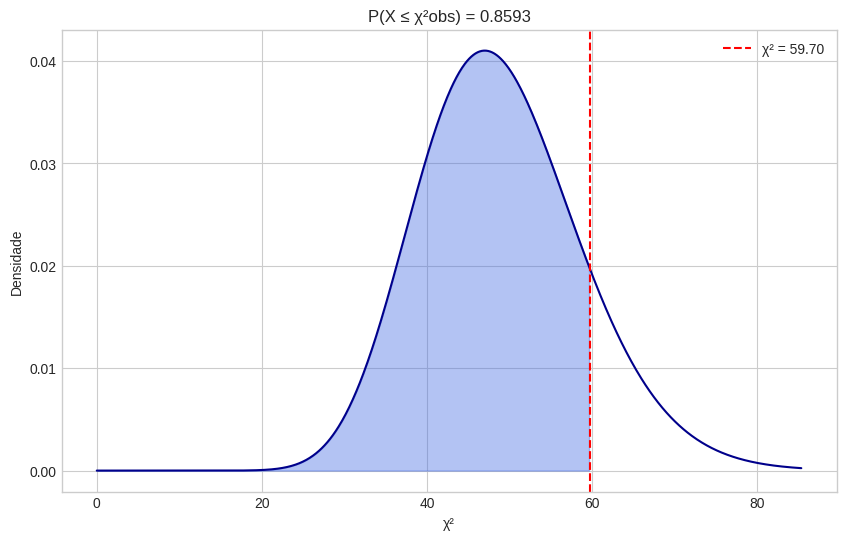

In [30]:
x = np.linspace(
    0,
    chi2.ppf(0.999, df_chi),
    1000
)

y = chi2.pdf(x, df_chi)

plt.figure(figsize=(10, 6))
plt.plot(x, y, color="darkblue")

mask = x <= chi_observado

plt.fill_between(
    x[mask],
    y[mask],
    alpha=0.4,
    color="royalblue"
)

plt.axvline(
    chi_observado,
    color="red",
    linestyle="--",
    label=f"χ² = {chi_observado:.2f}"
)

plt.title(
    f"P(X ≤ χ²obs) = {p_chi_acumulada:.4f}"
)

plt.xlabel("χ²")
plt.ylabel("Densidade")
plt.legend()
plt.show()


**Qui-quadrado — probabilidade entre dois valores**

Vamos calcular:

P(40≤X≤60).

In [31]:
a_chi = 40
b_chi = 60

p_chi_intervalo = (
    chi2.cdf(b_chi, df_chi)
    -
    chi2.cdf(a_chi, df_chi)
)

print(
    f"P({a_chi} ≤ X ≤ {b_chi}) = "
    f"{p_chi_intervalo:.6f}"
)


P(40 ≤ X ≤ 60) = 0.681913


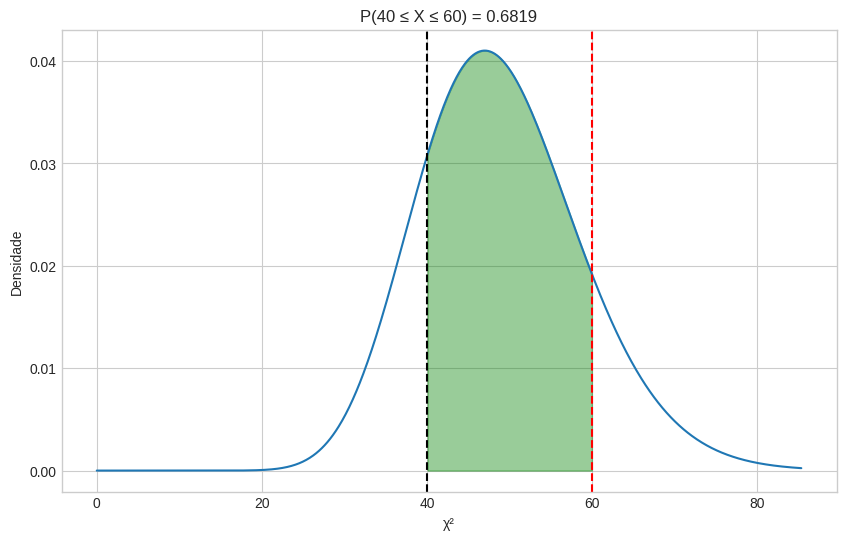

In [32]:
x = np.linspace(
    0,
    chi2.ppf(0.999, df_chi),
    1000
)

y = chi2.pdf(x, df_chi)

plt.figure(figsize=(10, 6))
plt.plot(x, y)

mask = (x >= a_chi) & (x <= b_chi)

plt.fill_between(
    x[mask],
    y[mask],
    alpha=0.4,
    color="green"
)

plt.axvline(a_chi, color="black", linestyle="--")
plt.axvline(b_chi, color="red", linestyle="--")

plt.title(
    f"P({a_chi} ≤ X ≤ {b_chi}) = "
    f"{p_chi_intervalo:.4f}"
)

plt.xlabel("χ²")
plt.ylabel("Densidade")
plt.show()


In [33]:
limite_chi = chi_observado

p_chi_acima = chi2.sf(
    limite_chi,
    df=df_chi
)

print(
    f"P(X > {limite_chi:.4f}) = "
    f"{p_chi_acima:.6f}"
)


P(X > 59.6992) = 0.140719


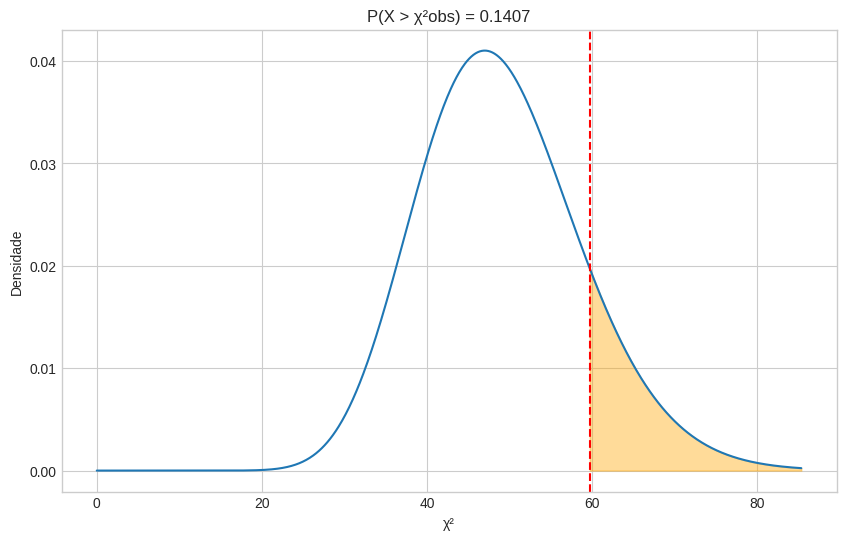

In [34]:
x = np.linspace(
    0,
    chi2.ppf(0.999, df_chi),
    1000
)

y = chi2.pdf(x, df_chi)

plt.figure(figsize=(10, 6))
plt.plot(x, y)

mask = x >= limite_chi

plt.fill_between(
    x[mask],
    y[mask],
    alpha=0.4,
    color="orange"
)

plt.axvline(
    limite_chi,
    color="red",
    linestyle="--"
)

plt.title(
    f"P(X > χ²obs) = {p_chi_acima:.4f}"
)

plt.xlabel("χ²")
plt.ylabel("Densidade")
plt.show()


In [35]:
percentil_95_chi = chi2.ppf(
    0.95,
    df=df_chi
)

print(
    f"Percentil 95% da qui-quadrado = "
    f"{percentil_95_chi:.4f}"
)


Percentil 95% da qui-quadrado = 66.3386


Esse valor representa o ponto abaixo do qual ficam 95% dos valores da distribuição qui-quadrado com n−1 graus de liberdade.

**Distribuição F de Fisher**

A distribuição F pode ser construída como a razão de duas variáveis qui-quadrado independentes, cada uma dividida por seus respectivos graus de liberdade:

F=X1/ν1X2/ν2

com:

X1∼χν12,X2∼χν22.

A densidade da distribuição F é:

f(x;ν1,ν2)=ν2ν2/2ν1ν1/2xν1/2−1(ν2+ν1x)(ν1+ν2)/2B(ν1/2,ν2/2)

para:

x>0.

A documentação do SciPy apresenta essa formulação e identifica dfn e dfd como os graus de liberdade do numerador e denominador.

O NIST também descreve a F como uma razão de duas distribuições qui-quadrado padronizadas pelos respectivos graus de liberdade.

**Aplicação biológica**

Para duas amostras independentes provenientes de populações Normais, uma estatística de razão de variâncias pode ser:

F=S12S22.

Sob a hipótese de variâncias populacionais iguais:

F∼Fν1,ν2

onde:

ν1=n1−1

e

ν2=n2−1.

Aqui vamos comparar:

    Iris virginica;

    Iris versicolor;

usando o comprimento da pétala.

In [36]:
virginica = df[
    df["species"] == "Iris-virginica"
]["petal_length"]

versicolor = df[
    df["species"] == "Iris-versicolor"
]["petal_length"]

n1 = len(virginica)
n2 = len(versicolor)

s2_virginica = virginica.var(ddof=1)
s2_versicolor = versicolor.var(ddof=1)

print("Iris virginica")
print(f"n = {n1}")
print(f"Variância = {s2_virginica:.4f}")

print("\nIris versicolor")
print(f"n = {n2}")
print(f"Variância = {s2_versicolor:.4f}")


Iris virginica
n = 50
Variância = 0.3046

Iris versicolor
n = 50
Variância = 0.2208


**Estatística F observada**

Para facilitar a interpretação da cauda superior, colocaremos a maior variância no numerador.

In [37]:
if s2_virginica >= s2_versicolor:
    grupo_numerador = "Iris virginica"
    grupo_denominador = "Iris versicolor"

    s2_num = s2_virginica
    s2_den = s2_versicolor

    n_num = n1
    n_den = n2
else:
    grupo_numerador = "Iris versicolor"
    grupo_denominador = "Iris virginica"

    s2_num = s2_versicolor
    s2_den = s2_virginica

    n_num = n2
    n_den = n1

F_observado = s2_num / s2_den

df1 = n_num - 1
df2 = n_den - 1

print(f"Numerador: {grupo_numerador}")
print(f"Denominador: {grupo_denominador}")
print(f"F observado = {F_observado:.4f}")
print(f"df1 = {df1}")
print(f"df2 = {df2}")

Numerador: Iris virginica
Denominador: Iris versicolor
F observado = 1.3794
df1 = 49
df2 = 49


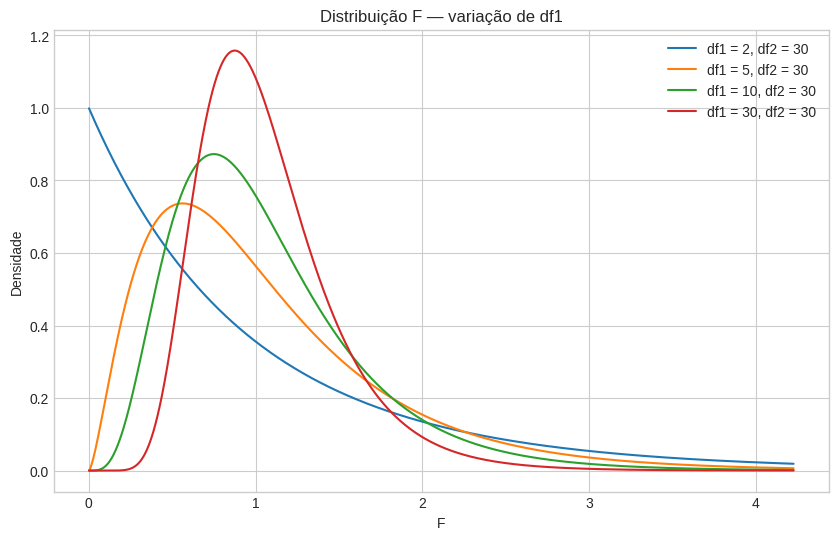

In [38]:
x = np.linspace(
    0.001,
    f.ppf(0.995, 5, 30),
    1000
)

dfn_values = [2, 5, 10, 30]
dfd = 30

plt.figure(figsize=(10, 6))

for dfn in dfn_values:
    plt.plot(
        x,
        f.pdf(x, dfn, dfd),
        label=f"df1 = {dfn}, df2 = {dfd}"
    )

plt.title("Distribuição F — variação de df1")
plt.xlabel("F")
plt.ylabel("Densidade")
plt.legend()
plt.show()


O grau de liberdade do numerador influencia a forma da distribuição, especialmente sua concentração e comportamento próximo de zero.

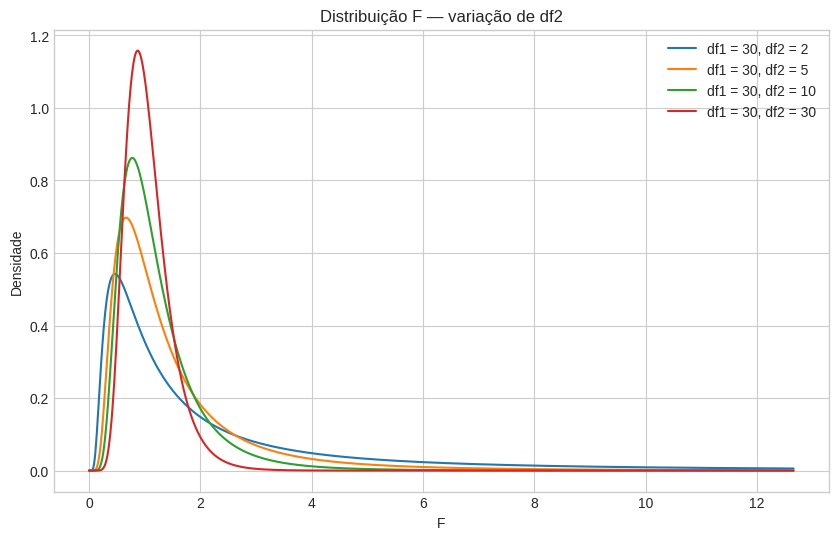

In [39]:
x = np.linspace(
    0.001,
    f.ppf(0.995, 30, 5),
    1000
)

dfn = 30
dfd_values = [2, 5, 10, 30]

plt.figure(figsize=(10, 6))

for dfd in dfd_values:
    plt.plot(
        x,
        f.pdf(x, dfn, dfd),
        label=f"df1 = {dfn}, df2 = {dfd}"
    )

plt.title("Distribuição F — variação de df2")
plt.xlabel("F")
plt.ylabel("Densidade")
plt.legend()
plt.show()


Alterar o grau de liberdade do denominador também modifica a assimetria e o comportamento da cauda direita.

Isso é importante porque os dois graus de liberdade possuem papéis diferentes na distribuição.

**Probabilidade acumulada**

Vamos calcular:

P(F≤Fobs).

In [40]:
p_f_acumulada = f.cdf(
    F_observado,
    df1,
    df2
)

print(
    f"P(F ≤ {F_observado:.4f}) = "
    f"{p_f_acumulada:.6f}"
)


P(F ≤ 1.3794) = 0.868127


Essa probabilidade não significa que uma espécie tenha determinada probabilidade de ser "mais variável".

Ela representa uma área da distribuição da razão de variâncias sob o modelo assumido.

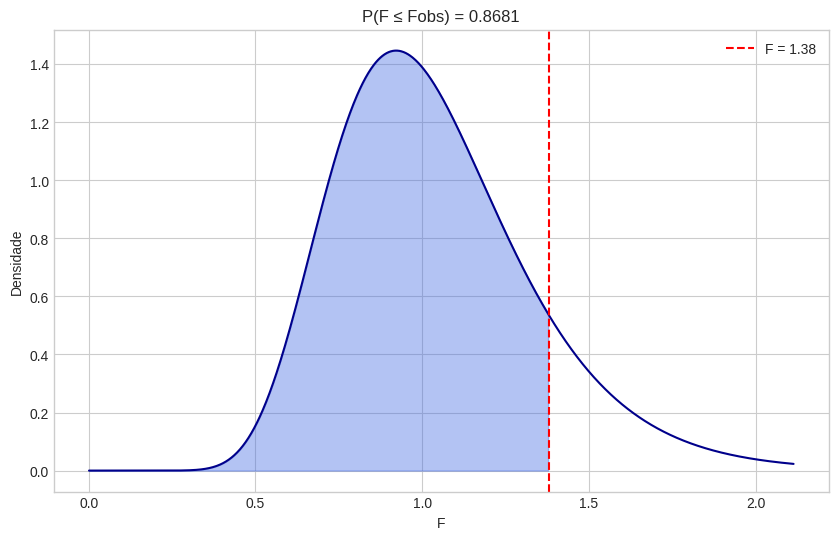

In [41]:
x = np.linspace(
    0.001,
    f.ppf(0.995, df1, df2),
    1000
)

y = f.pdf(x, df1, df2)

plt.figure(figsize=(10, 6))
plt.plot(x, y, color="darkblue")

mask = x <= F_observado

plt.fill_between(
    x[mask],
    y[mask],
    alpha=0.4,
    color="royalblue"
)

plt.axvline(
    F_observado,
    color="red",
    linestyle="--",
    label=f"F = {F_observado:.2f}"
)

plt.title(
    f"P(F ≤ Fobs) = {p_f_acumulada:.4f}"
)

plt.xlabel("F")
plt.ylabel("Densidade")
plt.legend()
plt.show()


**Probabilidade entre dois valores**

Vamos calcular:

P(1≤F≤2).



In [42]:
a_f = 1
b_f = 2

p_f_intervalo = (
    f.cdf(b_f, df1, df2)
    -
    f.cdf(a_f, df1, df2)
)

print(
    f"P({a_f} ≤ F ≤ {b_f}) = "
    f"{p_f_intervalo:.6f}"
)


P(1 ≤ F ≤ 2) = 0.491582


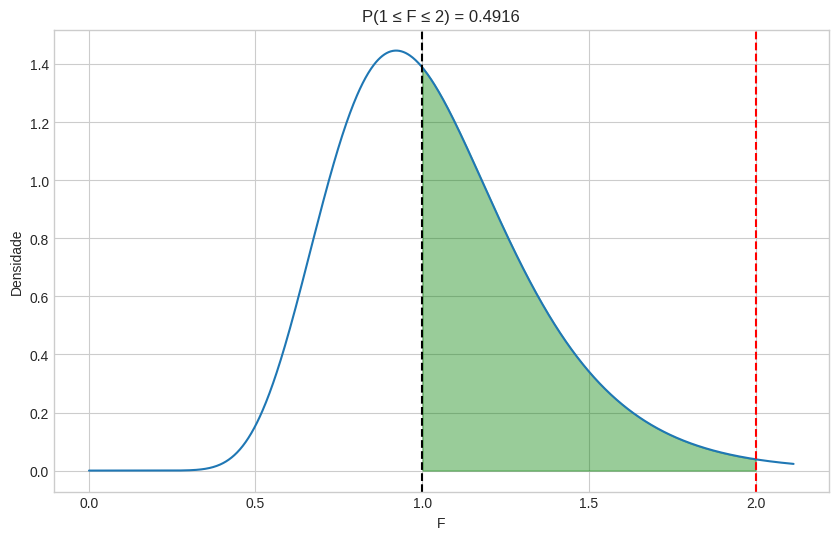

In [43]:
x = np.linspace(
    0.001,
    f.ppf(0.995, df1, df2),
    1000
)

y = f.pdf(x, df1, df2)

plt.figure(figsize=(10, 6))
plt.plot(x, y)

mask = (x >= a_f) & (x <= b_f)

plt.fill_between(
    x[mask],
    y[mask],
    alpha=0.4,
    color="green"
)

plt.axvline(a_f, color="black", linestyle="--")
plt.axvline(b_f, color="red", linestyle="--")

plt.title(
    f"P(1 ≤ F ≤ 2) = {p_f_intervalo:.4f}"
)

plt.xlabel("F")
plt.ylabel("Densidade")
plt.show()


**Probabilidade acima da razão observada**

Agora calcularemos:

P(F>Fobs).



In [44]:
p_f_acima = f.sf(
    F_observado,
    df1,
    df2
)

print(
    f"P(F > {F_observado:.4f}) = "
    f"{p_f_acima:.6f}"
)


P(F > 1.3794) = 0.131873


Essa é a probabilidade de observar uma razão de variâncias pelo menos tão grande quanto a observada, se as condições do modelo F forem válidas e a razão esperada sob a hipótese nula for 1.

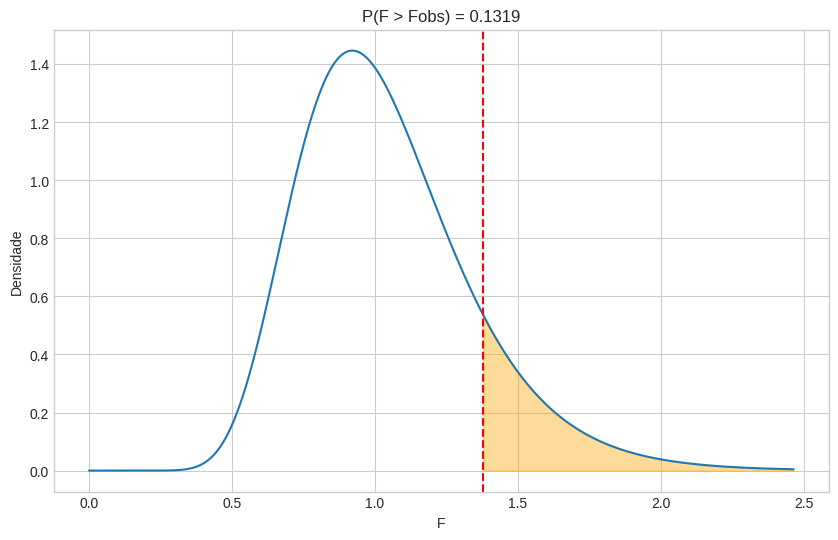

In [45]:
x = np.linspace(
    0.001,
    f.ppf(0.999, df1, df2),
    1000
)

y = f.pdf(x, df1, df2)

plt.figure(figsize=(10, 6))
plt.plot(x, y)

mask = x >= F_observado

plt.fill_between(
    x[mask],
    y[mask],
    alpha=0.4,
    color="orange"
)

plt.axvline(
    F_observado,
    color="red",
    linestyle="--"
)

plt.title(
    f"P(F > Fobs) = {p_f_acima:.4f}"
)

plt.xlabel("F")
plt.ylabel("Densidade")
plt.show()


Vamos calcular o percentil 95:

In [46]:
percentil_95_f = f.ppf(
    0.95,
    df1,
    df2
)

print(
    f"Percentil 95% da distribuição F = "
    f"{percentil_95_f:.4f}"
)


Percentil 95% da distribuição F = 1.6073


Esse valor representa o ponto que deixa 95% da distribuição F abaixo dele.

In [47]:
print(f"F observado = {F_observado:.4f}")
print(f"Percentil 95% = {percentil_95_f:.4f}")

if F_observado > percentil_95_f:
    print(
        "A razão observada está acima do percentil 95% "
        "da distribuição F."
    )
else:
    print(
        "A razão observada não está acima do percentil 95% "
        "da distribuição F."
    )


F observado = 1.3794
Percentil 95% = 1.6073
A razão observada não está acima do percentil 95% da distribuição F.


Organizando os principais resultados:

In [48]:
resultados = pd.DataFrame({
    "Distribuição": [
        "Normal",
        "t de Student",
        "Qui-quadrado",
        "F de Fisher"
    ],
    "Probabilidade acumulada": [
        p_acumulada,
        p_t_acumulada,
        p_chi_acumulada,
        p_f_acumulada
    ],
    "Probabilidade entre limites": [
        p_intervalo,
        p_t_intervalo,
        p_chi_intervalo,
        p_f_intervalo
    ],
    "Probabilidade acima": [
        p_acima,
        p_t_acima,
        p_chi_acima,
        p_f_acima
    ]
})

resultados


,Distribuição,Probabilidade acumulada,Probabilidade entre limites,Probabilidade acima
0,Normal,0.158609,0.632923,0.208468
1,t de Student,0.745809,0.948941,0.025530
2,Qui-quadrado,0.859281,0.681913,0.140719
3,F de Fisher,0.868127,0.491582,0.131873


In [49]:
percentis = pd.DataFrame({
    "Distribuição": [
        "Normal",
        "t de Student",
        "Qui-quadrado",
        "F de Fisher"
    ],
    "Percentil": [
        percentil_95_normal,
        percentil_975_t,
        percentil_95_chi,
        percentil_95_f
    ]
})

percentis


,Distribuição,Percentil
0,Normal,6.459786
1,t de Student,2.009575
2,Qui-quadrado,66.338649
3,F de Fisher,1.607289


Os valores dos percentis não devem ser comparados diretamente entre si, pois cada distribuição está em uma escala diferente.

**Verificação de normalidade visual**

Como as aplicações de t, qui-quadrado para variância e F dependem de pressupostos de normalidade, vamos examinar visualmente os dados.

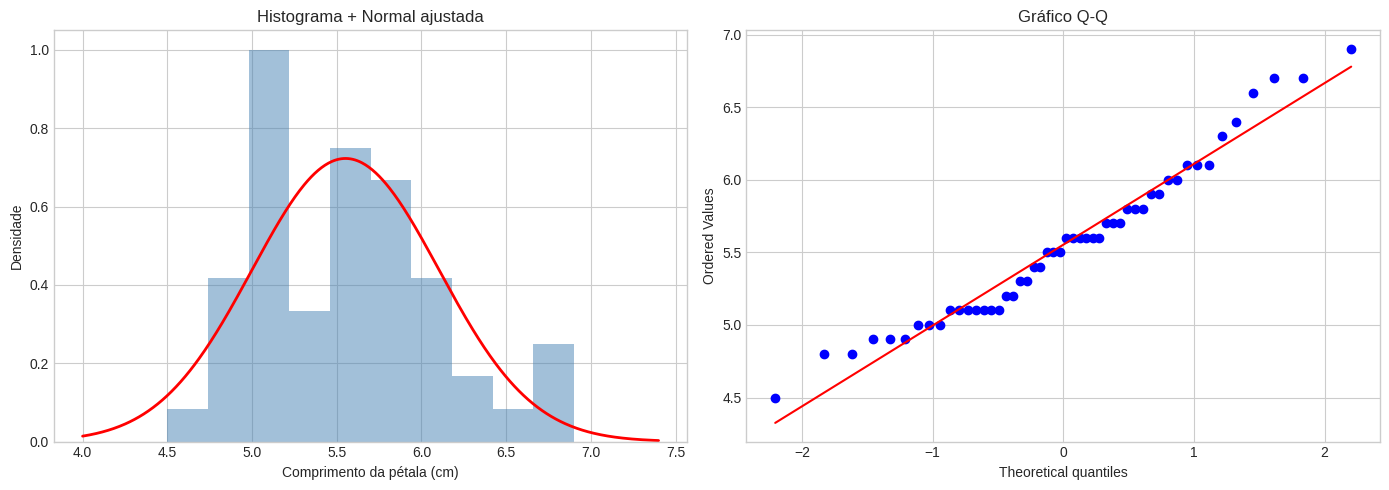

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    virginica,
    bins=10,
    density=True,
    alpha=0.5,
    color="steelblue"
)

x = np.linspace(
    virginica.min() - 0.5,
    virginica.max() + 0.5,
    500
)

axes[0].plot(
    x,
    norm.pdf(
        x,
        virginica.mean(),
        virginica.std(ddof=1)
    ),
    color="red",
    linewidth=2
)

axes[0].set_title("Histograma + Normal ajustada")
axes[0].set_xlabel("Comprimento da pétala (cm)")
axes[0].set_ylabel("Densidade")

stats.probplot(
    virginica,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title("Gráfico Q-Q")

plt.tight_layout()
plt.show()


**Teste de Shapiro-Wilk como diagnóstico complementar**

O teste abaixo será usado apenas como diagnóstico, não como prova absoluta de normalidade.

In [51]:
shapiro = stats.shapiro(virginica)

print(f"Estatística W = {shapiro.statistic:.4f}")
print(f"p-valor = {shapiro.pvalue:.6f}")


Estatística W = 0.9622
p-valor = 0.109775


A decisão estatística deve ser interpretada conjuntamente com:

    gráfico Q-Q;

    histograma;

    tamanho da amostra;

    conhecimento biológico;

    possíveis observações extremas.

Nenhum teste isolado demonstra que uma população real é exatamente Normal.

**Pressupostos da análise t**

A interpretação exata da estatística t utilizada neste notebook pressupõe, de maneira simplificada:

    observações independentes;

    amostra proveniente de uma população aproximadamente Normal;

    a média populacional de referência μ0 ser definida antes da análise;

    desvio-padrão populacional desconhecido;

    ausência de dependência entre as observações.

A distribuição t é uma distribuição de uma estatística amostral, não das medidas individuais.


**Pressupostos da análise qui-quadrado**

Para utilizar:

(n−1)S2σ02∼χn−12,

é necessário assumir que:

    as observações sejam independentes;

    a população seja Normal;

    a variância de referência σ02 seja especificada;

    a variância amostral seja calculada corretamente.

Se a população não for aproximadamente Normal, a distribuição exata da estatística pode não ser qui-quadrado.

**Pressupostos da distribuição F**

Para utilizar a razão:

F=S12S22,

como uma distribuição F, são importantes:

    independência entre os grupos;

    independência dentro de cada grupo;

    aproximadamente Normalidade nas duas populações;

    observações quantitativas;

    a hipótese correspondente à igualdade das variâncias, quando utilizada como teste clássico.

A distribuição F não diz que os comprimentos das pétalas são F-distribuídos.

Ela descreve a distribuição teórica da razão de variâncias amostrais sob condições específicas.

In [52]:
norm.pdf(5, mu_virginica, sigma_virginica)


np.float64(0.43835274585212536)

A pdf fornece a densidade no ponto.

A altura da curva não é, por si só, uma probabilidade.

Para uma variável contínua:

P(a<X<b)=∫abf(x) dx.

Ou seja, a probabilidade é uma área.

In [53]:
norm.cdf(5, mu_virginica, sigma_virginica)


np.float64(0.15860908908194882)

A CDF fornece:

P(X≤x).

In [54]:
norm.sf(5, mu_virginica, sigma_virginica)


np.float64(0.8413909109180512)

A função de sobrevivência fornece:

P(X>x).

In [55]:
norm.ppf(0.95, mu_virginica, sigma_virginica)


np.float64(6.459785991858182)

A PPF fornece o quantil correspondente a uma determinada probabilidade.

Por exemplo:

x=F−1(0,95)

é o valor abaixo do qual estão 95% dos valores da distribuição.

O SciPy disponibiliza essas funções para suas distribuições contínuas.

In [56]:
x = np.linspace(
    mu_virginica - 4*sigma_virginica,
    mu_virginica + 4*sigma_virginica,
    1000
)

y = norm.pdf(
    x,
    mu_virginica,
    sigma_virginica
)

x0 = 5.5

densidade_no_ponto = norm.pdf(
    x0,
    mu_virginica,
    sigma_virginica
)

prob_intervalo = (
    norm.cdf(
        x0 + 0.1,
        mu_virginica,
        sigma_virginica
    )
    -
    norm.cdf(
        x0 - 0.1,
        mu_virginica,
        sigma_virginica
    )
)

print(f"Densidade em x = {x0}: {densidade_no_ponto:.4f}")
print(
    f"P({x0-0.1} < X < {x0+0.1}) = "
    f"{prob_intervalo:.4f}"
)


Densidade em x = 5.5: 0.7197
P(5.4 < X < 5.6) = 0.1432


Esse exemplo evidencia que:

    a altura da curva em um ponto não deve ser interpretada como a probabilidade de obter exatamente aquele valor.

Para uma variável contínua, a probabilidade de obter exatamente um ponto específico é zero:

P(X=x)=0.

In [60]:
import pandas as pd
from IPython.display import display

# Síntese das quatro distribuições
sintese_distribuicoes = pd.DataFrame({
    "Distribuição": [
        "Normal",
        "t de Student",
        "Qui-quadrado",
        "F de Fisher"
    ],
    "Quantidade modelada": [
        "Medida contínua individual",
        "Estatística de média padronizada",
        "Estatística associada à variância",
        "Razão de duas variâncias"
    ],
    "Parâmetros principais": [
        "μ, σ",
        "ν (graus de liberdade)",
        "k (graus de liberdade)",
        "ν₁, ν₂ (graus de liberdade)"
    ],
    "Aplicação neste trabalho": [
        "Comprimento da pétala",
        "Média do comprimento da pétala versus uma média de referência",
        "Variância do comprimento da pétala versus uma variância de referência",
        "Razão das variâncias de Iris virginica e Iris versicolor"
    ]
})

# Exibir a tabela
display(sintese_distribuicoes)


,Distribuição,Quantidade modelada,Parâmetros principais,Aplicação neste trabalho
0,Normal,Medida contínua individual,"μ, σ",Comprimento da pétala
1,t de Student,Estatística de média padronizada,ν (graus de liberdade),Média do comprimento da pétala versus uma médi...
2,Qui-quadrado,Estatística associada à variância,k (graus de liberdade),Variância do comprimento da pétala versus uma ...
3,F de Fisher,Razão de duas variâncias,"ν₁, ν₂ (graus de liberdade)",Razão das variâncias de Iris virginica e Iris ...


A principal diferença conceitual é que a Normal foi usada como modelo para uma medida individual, enquanto t, qui-quadrado e F foram usadas para representar estatísticas calculadas a partir de amostras.

**Limitações da base Iris**

A base apresenta algumas limitações importantes.
Tamanho e composição

Embora existam 150 observações, elas estão organizadas em apenas três grupos de 50 plantas.
Generalização

Os resultados não devem ser automaticamente generalizados para todas as plantas das espécies.

A própria UCI descreve o conjunto como um conjunto clássico e pequeno de dados, com 50 instâncias por classe.
Independência

A base não deve ser interpretada automaticamente como se representasse uma amostra aleatória de todas as plantas existentes dessas espécies.
Origem dos dados

O conjunto possui uma história específica e não foi coletado originalmente para responder exatamente às perguntas formuladas neste trabalho.
Normalidade

As curvas Normal, t, qui-quadrado e F são modelos matemáticos. O simples fato de conseguirmos desenhar uma curva não demonstra que os dados obedecem ao modelo.

**Conclusão**

A análise mostrou como quatro distribuições de probabilidade podem assumir papéis diferentes em uma investigação biológica.

A distribuição Normal pode ser usada como modelo para uma característica contínua, como o comprimento de uma pétala. Nesse caso, a curva representa uma hipótese sobre a distribuição de uma nova observação individual.

A distribuição t de Student é adequada para representar a incerteza associada a uma média quando a variância populacional é desconhecida e determinadas condições são satisfeitas. A variável aleatória relevante é uma estatística padronizada, e não a medida biológica original.

A distribuição qui-quadrado aparece naturalmente na análise da variância de uma amostra Normal. A quantidade modelada é:

(n−1)S2σ2.

Finalmente, a distribuição F permite estudar uma razão entre duas variâncias. No caso analisado, ela possibilita investigar a variabilidade do comprimento das pétalas de duas espécies sob um modelo de igualdade das variâncias.

Portanto, uma curva de distribuição não deve ser interpretada simplesmente como uma descrição visual dos dados. É necessário identificar:

    qual é a variável aleatória;

    quais são seus parâmetros;

    quais hipóteses permitem utilizar a distribuição;

    qual quantidade biológica ou estatística está sendo modelada;

    e qual é o significado da área sob a curva.

As probabilidades calculadas por cdf, sf e intervalos entre limites correspondem a áreas sob as densidades, enquanto ppf permite encontrar valores associados a percentis. A função pdf, por outro lado, fornece uma densidade e não uma probabilidade pontual.


**Referências**
Base de dados

FISHER, R. A. Iris. UCI Machine Learning Repository, 1936. DOI: 10.24432/C56C76.

UCI Machine Learning Repository. Iris Dataset.
https://archive.ics.uci.edu/dataset/53/iris

A documentação da UCI informa o número de observações, espécies, variáveis, unidades, ausência de dados faltantes e significado de cada linha.
SciPy

SCI-PY COMMUNITY. scipy.stats.norm — Normal distribution. SciPy Reference Guide.

SCI-PY COMMUNITY. scipy.stats.t — Student's t distribution. SciPy Reference Guide.

SCI-PY COMMUNITY. scipy.stats.chi2 — Chi-squared distribution. SciPy Reference Guide.

SCI-PY COMMUNITY. scipy.stats.f — F distribution. SciPy Reference Guide.
Teoria estatística

NIST/SEMATECH. e-Handbook of Statistical Methods — Probability Distributions. National Institute of Standards and Technology.

In [57]:
print("=" * 60)
print("RESUMO FINAL")
print("=" * 60)

print("\nNORMAL")
print(f"Média: {mu_virginica:.4f} cm")
print(f"Desvio-padrão: {sigma_virginica:.4f} cm")
print(f"P(X ≤ 5): {p_acumulada:.4f}")
print(f"P(5 ≤ X ≤ 6): {p_intervalo:.4f}")
print(f"P(X > 6): {p_acima:.4f}")
print(f"Percentil 95%: {percentil_95_normal:.4f} cm")

print("\nT DE STUDENT")
print(f"t observado: {t_observado:.4f}")
print(f"df: {df_t}")
print(f"P(T ≤ t_obs): {p_t_acumulada:.4f}")
print(f"P(-2 ≤ T ≤ 2): {p_t_intervalo:.4f}")
print(f"P(T > 2): {p_t_acima:.4f}")
print(f"Percentil 97,5%: {percentil_975_t:.4f}")

print("\nQUI-QUADRADO")
print(f"Variância amostral: {s2:.4f} cm²")
print(f"χ² observado: {chi_observado:.4f}")
print(f"df: {df_chi}")
print(f"P(X ≤ χ²obs): {p_chi_acumulada:.4f}")
print(f"P(40 ≤ X ≤ 60): {p_chi_intervalo:.4f}")
print(f"P(X > χ²obs): {p_chi_acima:.4f}")
print(f"Percentil 95%: {percentil_95_chi:.4f}")

print("\nF DE FISHER")
print(f"F observado: {F_observado:.4f}")
print(f"df1: {df1}")
print(f"df2: {df2}")
print(f"P(F ≤ Fobs): {p_f_acumulada:.4f}")
print(f"P(1 ≤ F ≤ 2): {p_f_intervalo:.4f}")
print(f"P(F > Fobs): {p_f_acima:.4f}")
print(f"Percentil 95%: {percentil_95_f:.4f}")

print("\n" + "=" * 60)


RESUMO FINAL

NORMAL
Média: 5.5520 cm
Desvio-padrão: 0.5519 cm
P(X ≤ 5): 0.1586
P(5 ≤ X ≤ 6): 0.6329
P(X > 6): 0.2085
Percentil 95%: 6.4598 cm

T DE STUDENT
t observado: 0.6662
df: 49
P(T ≤ t_obs): 0.7458
P(-2 ≤ T ≤ 2): 0.9489
P(T > 2): 0.0255
Percentil 97,5%: 2.0096

QUI-QUADRADO
Variância amostral: 0.3046 cm²
χ² observado: 59.6992
df: 49
P(X ≤ χ²obs): 0.8593
P(40 ≤ X ≤ 60): 0.6819
P(X > χ²obs): 0.1407
Percentil 95%: 66.3386

F DE FISHER
F observado: 1.3794
df1: 49
df2: 49
P(F ≤ Fobs): 0.8681
P(1 ≤ F ≤ 2): 0.4916
P(F > Fobs): 0.1319
Percentil 95%: 1.6073

